# PyHermes End-to-End Example

This notebook presents a complete PyHermes workflow using the example scripts in `examples/`. The code cells are unchanged; only the narrative has been reorganized so that each stage of the pipeline is easier to follow.


In [1]:
from pyhermes.base.convols import Convols
from pyhermes.theory.counting import Counting
from pyhermes.theory.corr2pcf import Corr_2PCF, calc_DD_mean_r
from pyhermes.theory.corr3pcf import Corr_3PCF, calc_DDD_mean_mc
from pyhermes.param.parambase import read_param
from pyhermes.utils import math_util
from pyhermes.io import WindowFunc, ConvolsData, CountingData, Corr2PCFData, Corr3PCFData
import matplotlib.pyplot as plt
import numpy as np

# PyHermes Full Example

This notebook reorganizes the complete PyHermes workflow from raw particle positions to counting, 2PCF, and 3PCF measurements.

## What this notebook covers

1. build the multiresolution field with `Convols`
2. apply spherical smoothing and inspect the filtered field
3. run `Counting` on random points
4. compute the 2PCF and compare filtered vs. unfiltered results
5. compute the 3PCF and compare particle-center vs. random-center estimators

## Conventions used below

- All fields (`epsilon`, `n(x)`) are normalized in grid space, so the sum over all grid cells is 1.
- The uniform random field is constant in grid space: `R = 1 / V`, where `V = L^3`.
- Therefore, `<RR> = R^2` and `<RRR> = R^3`.
- Physical coordinates satisfy `x_phys in [0, box_size)` in `Mpc/h`.
- Scaled grid coordinates satisfy `x_scaled = x_phys * scale_factor in [0, L)`.
- The reduced 3PCF `Q(theta)` is evaluated from convolution-based `xi(r)` and Monte Carlo estimates of `zeta(theta)`.


## 1. Build the multiresolution field with `Convols`

This first stage reads the particle catalog, constructs the PyHermes multiresolution representation, and writes it to disk for reuse in later tasks.


### Driver script

The external script used in this section is:

```python
# run_convols.py
convols_params = read_param(config_path='./configs/param_convols.yaml')
convols = Convols(param_task=convols_params)
convols.run(overwrite=True)
```


### Configuration

The corresponding YAML configuration is:

```yaml
# configs/param_convols.yaml
Convols:
   J: 8
   fin:
      path: "https://pyhermes.astroslacker.com/_downloads/906e0695649e3634a5fe8081b9ab2086/quijote10000.bin"
      format: "generic_pos"
   fout_path: "./output/quijote_sfc.pkl"
   phi_resolution: 1024
   box_size: 1000
   wavelet_mode: "db2"
   wavelet_level: 10
   bandwidth: 1
```


In [2]:
! mpirun -np 4 python run_convols.py

13:13:38 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_convols.yaml'
13:13:38 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
13:13:38 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
13:13:38 - INFO - pyhermes.param.parambase:ParamBase - Default 'Convols.fin.path' from './data.bin' to 'https://pyhermes.astroslacker.com/_downloads/906e0695649e3634a5fe8081b9ab2086/quijote10000.bin'
13:13:38 - INFO - pyhermes.param.parambase:ParamBase - Default 'Convols.fout_path' from 'empty' to './output/quijote_sfc.pkl'

13:13:38 - INFO - pyhermes.pipeline.pipeline:Convols - The task will run on 4 MPI ranks with 1 threads per rank
13:13:38 - INFO - pyhermes.io.funcs:read_particle_data - Selected input particle format: generic_pos
13:13:39 - INFO - pyhermes.io.funcs:dl_rich_pbar - File 'quijote10000.bin' already exists. Skipping download.
13:13:39 - INFO - pyhermes.io.funcs:read_generic_p

In [3]:
# read convols
D = ConvolsData(data_path='./output/quijote_sfc.pkl')
R = 1 / D.V

13:13:43 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote_sfc.pkl <---
13:13:43 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -3.399e-06, Max = 1.305e-05, Mean = 5.96e-08, Sum = 1


### Apply a spherical smoothing filter

After loading the saved `ConvolsData`, we construct a spherical window with radius `R = 20` and apply it to the field. This filtered field will be reused in later comparisons.


In [4]:
win_params = {"type": "sphere", "len_args": {"R": 20}}
filter_sph20 = WindowFunc(win_params, D.convols_info)
D_sph20 = D @ filter_sph20

## 2. Run `Counting` on random points

`Counting` samples the smoothed field at many random positions. This is useful for inspecting the one-point distribution after smoothing.


### Driver script

```python
# run_counting.py

counting_params = read_param(config_path='./configs/param_counting.yaml')
# counting_params['Counting']['window'] = {}
# counting_params['Counting']['fout_path'] = "./output/quijote_counting.pkl"
counting = Counting(param_task=counting_params)
counting.run(overwrite=True)
```


### Configuration

```yaml
# configs/param_counting.yaml
Counting:
  N_randoms: 10000000
  convols_data_path: "./output/quijote_sfc.pkl" 
  fout_path: "./output/quijote_counting_sph20.pkl"
  window:
    type: sphere
    len_args:
      R: 20
```


In [5]:
! mpirun -np 4 python run_counting.py

13:13:53 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_counting.yaml'
13:13:53 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
13:13:53 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
13:13:53 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.N_randoms' from '1000000' to '10000000'
13:13:53 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.convols_data_path' from 'empty' to './output/quijote_sfc.pkl'
13:13:53 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.fout_path' from 'empty' to './output/quijote_counting_sph20.pkl'
13:13:53 - INFO - pyhermes.param.parambase:ParamBase - Default 'Counting.window.type' from 'empty' to 'sphere'
13:13:53 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Counting.window.len_args.R'

13:13:53 - INFO - pyhermes.pipeline.pipeline:Counting - The task will run on 4 MPI ranks

13:13:58 - INFO - pyhermes.io.base:CountingData - Reading Counting data from ---> ./output/quijote_counting_sph20.pkl <---
13:13:58 - INFO - pyhermes.io.base:CountingData - nx: Shape(10000000,), Min = -7.953e-05, Max = 0.002404, Mean = 0.0004068


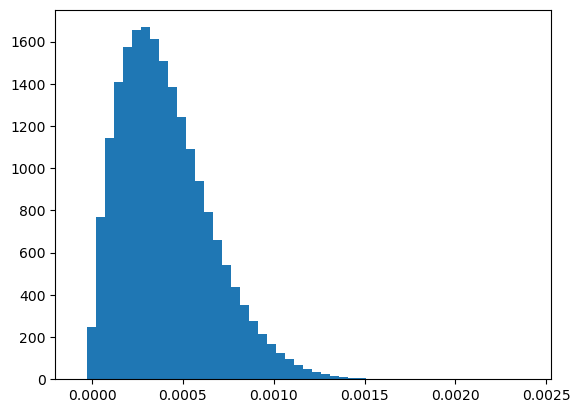

In [6]:
# read counting
counting = CountingData(data_path="./output/quijote_counting_sph20.pkl")
# counting = CountingData(data_path="./output/quijote_counting.pkl")

plt.hist(counting.nx, bins=50, density=True)
plt.show()

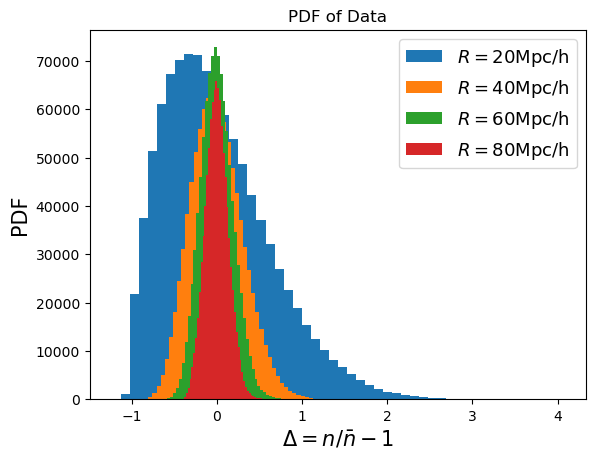

In [7]:
rand = math_util.random_points_box(10**6, D.box_size)
win_params = dict(type="sphere", len_args={})
for smooth_radius in [20, 40, 60, 80]:
    win_params["len_args"]["R"] = smooth_radius
    filter = WindowFunc(win_params, D.convols_info)
    n = D.n_at_pos(rand, filter=filter)
    plt.hist(n/n.mean()-1, bins=50, density=False, label=rf'$R={smooth_radius}$Mpc/h')

plt.title('PDF of Data')
plt.xlabel(r'$\Delta=n/{\bar n}-1$', fontsize=15)
plt.ylabel('PDF', fontsize=15)
plt.legend(fontsize=13)
plt.show()

## 3. Measure the 2PCF

This section runs the built-in 2PCF pipeline, then compares the stored result with a manual calculation based on a filtered field.


### Driver script

```python
# run_2pcf.py
corr2pcf_params = read_param(config_path='./configs/param_2pcf.yaml')
# corr2pcf_params['Corr_2PCF']['n_r'] = 20
# corr2pcf_params['Corr_2PCF']['fout_path'] = "./output/quijote_2pcf_num20.pkl"
corr2pcf = Corr_2PCF(param_task=corr2pcf_params)
corr2pcf.run(overwrite=True)
```


### Configuration

```yaml
# configs/param_2pcf.yaml
Corr_2PCF:
   convols_data_path: "./output/quijote_sfc.pkl" 
   fout_path: "./output/quijote_2pcf.pkl"
   r_min: 1.0
   r_max: 150.0
   n_r: 30
```


In [8]:
! mpirun -np 4 python run_2pcf.py

13:14:14 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf.yaml'
13:14:14 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
13:14:14 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
13:14:14 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data_path' from 'empty' to './output/quijote_sfc.pkl'
13:14:14 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.fout_path' from 'empty' to './output/quijote_2pcf.pkl'

13:14:14 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - The task will run on 4 MPI ranks with 1 threads per rank
13:14:14 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote_sfc.pkl <---
13:14:14 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -3.399e-06, Max = 1.305e-05, Mean = 5.96e-08, Sum = 1
13:14:14 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Start to calcu

In [9]:
# read corr2pcf data
corr2pcf_data = Corr2PCFData(data_path='./output/quijote_2pcf.pkl')

13:14:28 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> ./output/quijote_2pcf.pkl <---
13:14:28 - INFO - pyhermes.io.base:Corr2PCFData - r: Num = 30, Min = 1, Max = 150
13:14:28 - INFO - pyhermes.io.base:Corr2PCFData - xi: Mean = 1.386, Min = -0.001638, Max = 39.28


In [10]:
deltaD = D - R
deltaD_sph20 = deltaD @ filter_sph20
RR = R ** 2

r_arr = np.linspace(1, 150, 30)
xi_arr = np.zeros_like(r_arr)
for i, r in enumerate(r_arr):
    win_params = {"type": "shell", "len_args": {"R": r}}
    win_shell = WindowFunc(win_params, D.convols_info)

    deltaDD = deltaD_sph20 @ win_shell * deltaD_sph20
    
    xi_arr[i] = deltaDD.as_array().mean() / RR 

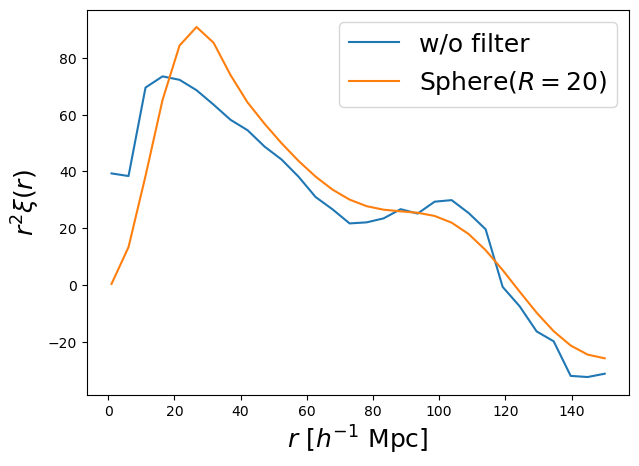

In [11]:
plt.figure(figsize=(7, 5))
plt.plot(corr2pcf_data.r, corr2pcf_data.xi*corr2pcf_data.r**2, label='w/o filter')
plt.plot(r_arr, xi_arr*r_arr**2, label=rf'Sphere($R=20$)')

plt.xlabel(r'$r\ [h^{-1}\ \mathrm{Mpc}]$', fontsize='18')
plt.ylabel(r'$r^2 \xi(r)$', fontsize='18')
plt.legend(loc='best', fontsize='18')
plt.show()

### Window customization experiment

To illustrate how the measured 2PCF depends on smoothing, the next cells define a custom cosine window and compare it with the default spherical filter and a Gaussian filter.


In [12]:
from numba import njit

@njit
def window_function_cosine_numba(ki, kj, kk, R):
    k = np.sqrt(ki**2 + kj**2 + kk**2)
    Phase = 2 * np.pi * k * R
    result = np.cos(Phase)
    return result

In [13]:
win_params = {"type": "gaussian", "len_args": {"R": 8}}
filter_gauss8 = WindowFunc(win_params, D.convols_info)
deltaD_gauss8 = deltaD @ filter_gauss8

xi2_arr = np.zeros_like(r_arr)
for i, r in enumerate(r_arr):
    win_params = {"func": window_function_cosine_numba, "len_args": {"R": r}}
    win_cos = WindowFunc(win_params, D.convols_info)

    deltaDD = deltaD_gauss8 @ win_cos * deltaD_gauss8
    
    xi2_arr[i] = deltaDD.as_array().mean() / RR

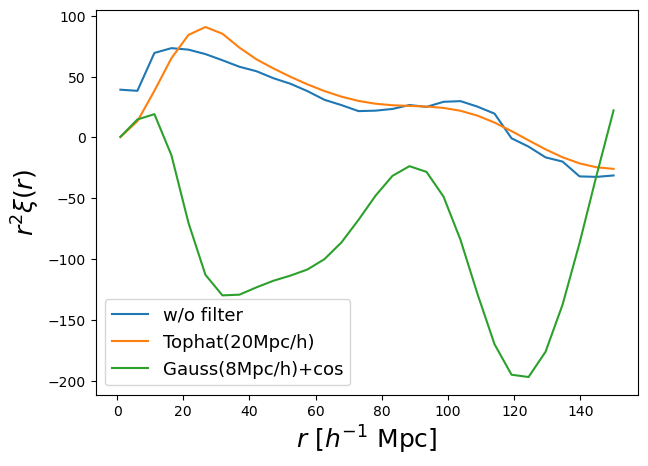

In [14]:
plt.figure(figsize=(7, 5))
plt.plot(corr2pcf_data.r, corr2pcf_data.xi*corr2pcf_data.r**2, label='w/o filter')
plt.plot(r_arr, xi_arr*r_arr**2, label=rf'Tophat(20Mpc/h)')
plt.plot(r_arr, xi2_arr*r_arr**2, label=rf'Gauss(8Mpc/h)+cos')

plt.xlabel(r'$r\ [h^{-1}\ \mathrm{Mpc}]$', fontsize='18')
plt.ylabel(r'$r^2 \xi(r)$', fontsize='18')
plt.legend(loc='best', fontsize='13')
plt.show()

## 4. Measure the 3PCF

This section runs the standard 3PCF task, compares the particle-center and random-center outputs, and then reproduces the reduced 3PCF calculation step by step.


### Driver script

```python
# run_3pcf.py
corr3pcf_params = read_param(config_path='./configs/param_3pcf.yaml')
# corr3pcf_params['Corr_3PCF']['center'] = 'particle'
# corr3pcf_params['Corr_3PCF']['fout_path'] = "./output/quijote_3pcf_part.pkl"
corr3pcf = Corr_3PCF(param_task=corr3pcf_params)
corr3pcf.run(overwrite=True)
```


### Configuration

```yaml
# configs/param_3pcf.yaml
Corr_3PCF:
   convols_data_path: "./output/quijote_sfc.pkl" 
   fout_path: "./output/quijote_3pcf_rand1e7.pkl"
   window2:
      type: "sphere"
      len_args:
         R: 5
   window3:
      type: "sphere"
      len_args:
         R: 5
   r12: 20.0
   r13: 40.0
   n_theta: 20
   n_rot: 20
   # center: "particle"
   center: "random"
   n_rand: 10000000
   base_seed: 42
```


In [15]:
! mpirun -np 4 python run_3pcf.py

13:15:08 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_3pcf.yaml'
13:15:08 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
13:15:08 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
13:15:08 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.convols_data_path' from 'empty' to './output/quijote_sfc.pkl'
13:15:08 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.fout_path' from 'empty' to './output/quijote_3pcf_rand1e7.pkl'
13:15:08 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.window2.type' from 'empty' to 'sphere'
13:15:08 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Corr_3PCF.window2.len_args.R'
13:15:08 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.window3.type' from 'empty' to 'sphere'
13:15:08 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Corr_3

In [16]:
# read corr3pcf data
corr3pcf_data_part = Corr3PCFData(data_path='./output/quijote_3pcf_part.pkl')
corr3pcf_data_rand = Corr3PCFData(data_path='./output/quijote_3pcf_rand1e7.pkl')

13:28:07 - INFO - pyhermes.io.base:Corr3PCFData - Reading 3PCF data from ---> ./output/quijote_3pcf_part.pkl <---
13:28:07 - INFO - pyhermes.io.base:Corr3PCFData - Reading 3PCF data from ---> ./output/quijote_3pcf_rand1e7.pkl <---


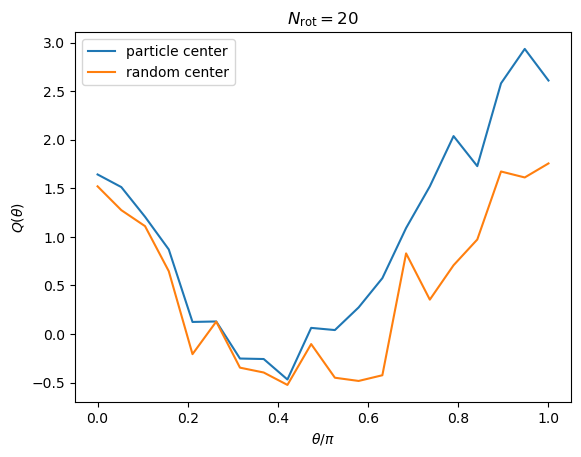

In [17]:
plt.plot(corr3pcf_data_part.theta/np.pi, corr3pcf_data_part.Q, label='particle center')
plt.plot(corr3pcf_data_rand.theta/np.pi, corr3pcf_data_rand.Q, label='random center')
plt.legend()
plt.title(r'$N_{\rm rot}=20$')
plt.xlabel(r"$\theta/\pi$")
plt.ylabel(r"$Q(\theta)$")
plt.show()

### Definitions used in the manual 3PCF check

The next few cells reproduce the reduced 3PCF from the saved field and smoothed windows. The normalization conventions are:

$$
n_R = \frac{1}{V}, \qquad \langle R \rangle = n_R, \qquad \langle RR \rangle = n_R^2, \qquad \langle RRR \rangle = n_R^3
$$

The pairwise correlations are

$$
\xi_{12} = \frac{\langle D_1 D_{W2} \rangle}{\langle R_1 R_2 \rangle} - 1, \qquad
\xi_{13} = \frac{\langle D_1 D_{W3} \rangle}{\langle R_1 R_3 \rangle} - 1, \qquad
\xi_{23} = \frac{\langle D_{W2} D_{W3} \rangle}{\langle R_2 R_3 \rangle} - 1
$$

For the three-point term,

$$
\zeta' = \frac{\langle D_1 D_{W2} D_{W3} \rangle}{\langle R_1 R_2 R_3 \rangle} - 1
$$

and equivalently,

$$
\zeta = \frac{\langle (D_1-R_1)(D_{W2}-R_2)(D_{W3}-R_3) \rangle}{\langle R_1 R_2 R_3 \rangle} = \zeta' - \xi_{12} - \xi_{13} - \xi_{23}
$$

The hierarchical normalization is

$$
\zeta_H = \xi_{12}\xi_{23} + \xi_{13}\xi_{23} + \xi_{12}\xi_{13}, \qquad Q = \zeta / \zeta_H
$$


In [18]:
D = ConvolsData(data_path="./output/quijote_sfc.pkl")
R = 1.0 / D.V
RR = R ** 2
RRR = R ** 3

filter_sph5 = WindowFunc({"type": "sphere", "len_args": {"R": 5}}, D.convols_info)
D_sph5 = D @ filter_sph5
deltaD = D - R
deltaD_sph5 = deltaD @ filter_sph5

n_rot = 20
n_theta = 20
theta_values = np.linspace(0.0, np.pi, n_theta)

13:28:23 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote_sfc.pkl <---
13:28:23 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -3.399e-06, Max = 1.305e-05, Mean = 5.96e-08, Sum = 1


In [19]:
r12, r13 = 20.0, 40.0
r23 = math_util.third_side(r12, r13, theta_values)

xi12 = calc_DD_mean_r(r12, deltaD, deltaD_sph5) / RR
xi13 = calc_DD_mean_r(r13, deltaD, deltaD_sph5) / RR
xi23 = np.array([calc_DD_mean_r(r, deltaD_sph5, deltaD_sph5) / RR for r in r23])

### Method 1: particle centers

In this estimator, triangle centers are taken directly from particle positions:

- `DDD = <D_1 D_{W2} D_{W3}>`
- `zeta' = DDD / <R_1 R_2 R_3> - 1`
- `zeta = zeta' - (xi_12 + xi_13 + xi_23)`


In [20]:
pos = D.get_particle_data()
pos_scaled = pos * D.scale_factor
r12_scaled = r12 * D.scale_factor
r13_scaled = r13 * D.scale_factor

zeta_p = np.empty_like(theta_values, dtype=np.float64)
for it, th in enumerate(theta_values):
    DDD = calc_DDD_mean_mc(r12_scaled, r13_scaled, th, pos_scaled, n_rot, 
                           D, D_sph5, D_sph5, center="particle", 
                           seed_base_rot=43, theta_index=it)
    zeta_p[it] = DDD / RRR - 1

zeta = zeta_p - xi12 - xi23 - xi13
zeta_H = xi12 * xi23 + xi13 * xi23 + xi12 * xi13
Q1_theta = zeta / zeta_H

13:28:39 - INFO - pyhermes.io.funcs:read_particle_data - Selected input particle format: generic_pos


13:28:40 - INFO - pyhermes.io.funcs:dl_rich_pbar - File 'quijote10000.bin' already exists. Skipping download.
13:28:40 - INFO - pyhermes.io.funcs:read_generic_pos_only - Reading paricle data from ---> quijote10000.bin <---


### Method 2: random centers

In this estimator, triangle centers are sampled randomly in the box:

- `deltaDDD = <(D_1-R_1)(D_{W2}-R_2)(D_{W3}-R_3)>`
- `zeta = deltaDDD / <R_1 R_2 R_3>`

This is the form typically used in the random-center pipeline above.


In [21]:
rand_scaled = math_util.random_points_box(N=10_000_000, box_size=D.L, seed=1000045)
r12_scaled = r12 * D.scale_factor
r13_scaled = r13 * D.scale_factor

zeta = np.empty_like(theta_values, dtype=np.float64)
for it, th in enumerate(theta_values):
    deltaDDD = calc_DDD_mean_mc(r12_scaled, r13_scaled, th, rand_scaled, n_rot, 
                                deltaD, deltaD_sph5, deltaD_sph5, center="random", 
                                seed_base_rot=43, theta_index=it)
    zeta[it] = deltaDDD / RRR

zeta_H = xi12 * xi23 + xi13 * xi23 + xi12 * xi13
Q2_theta = zeta / zeta_H

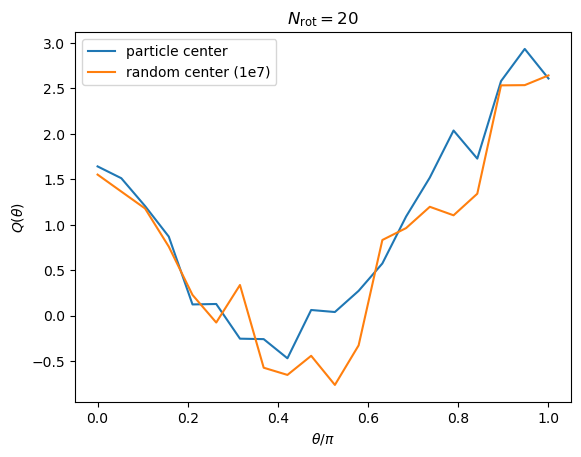

In [22]:
plt.plot(theta_values/np.pi, Q1_theta, label='particle center')
plt.plot(theta_values/np.pi, Q2_theta, label='random center (1e7)')
plt.legend()
plt.title(r'$N_{\rm rot}=20$')
plt.xlabel(r"$\theta/\pi$")
plt.ylabel(r"$Q(\theta)$")
plt.show()